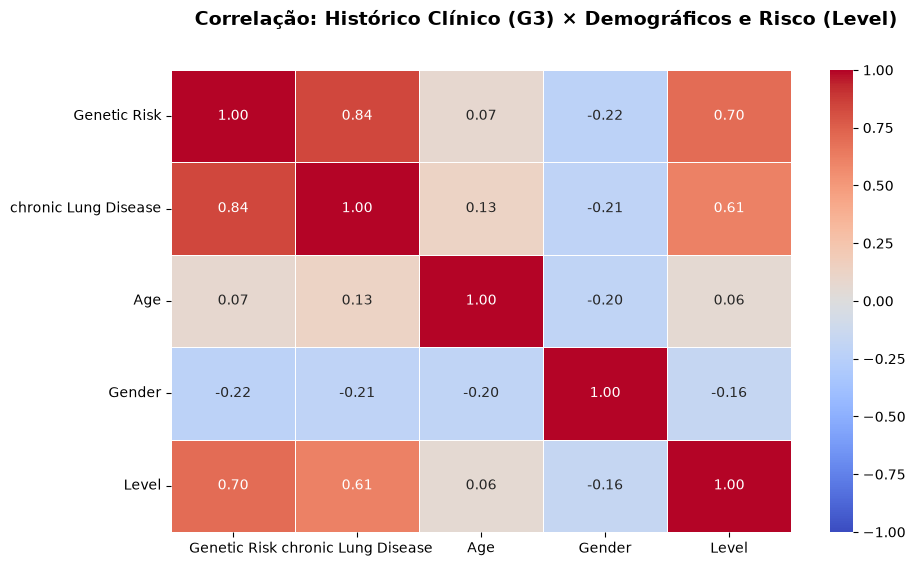


 ╔══════════════════════════════════════════════════════════════════╗
 ║  INSIGHTS — Correlação Histórico Clínico × Level × Demografia    ║
 ╠══════════════════════════════════════════════════════════════════╣
 ║  • O Risco Genético possui a maior correlação positiva com o     ║
 ║    Risco de Câncer. Isso indica um maior fator de risco, porém   ║
 ║    esperado. O mesmo ocorre, só que menos, com Doença Crônica.   ║
 ║  • Risco Genético e Doença Crônica possuem uma correlação muito  ║
 ║    alta entre si. Com isso, dá pra inferir que elas andam juntas ║
 ║    e dão informações redundantes ao modelo (multicolinearidade). ║
 ║    Pessoas com predisposição genética alta frequentemente        ║
 ║    desenvolvem doenças pulmonares crônicas.                      ║    
 ║  • Dataset indica pouca correlação com a idade e nenhuma com o   ║
 ║    gênero quanto ao Histórico Clínico e Risco de Câncer.         ║
 ╚══════════════════════════════════════════════════════════════════╝



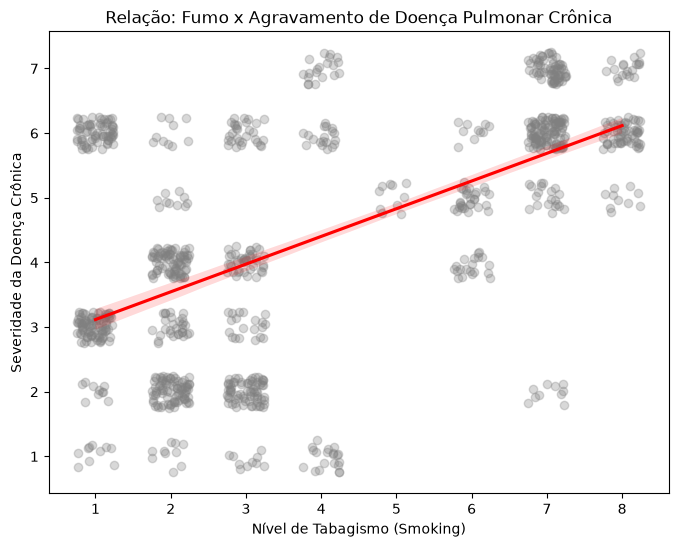

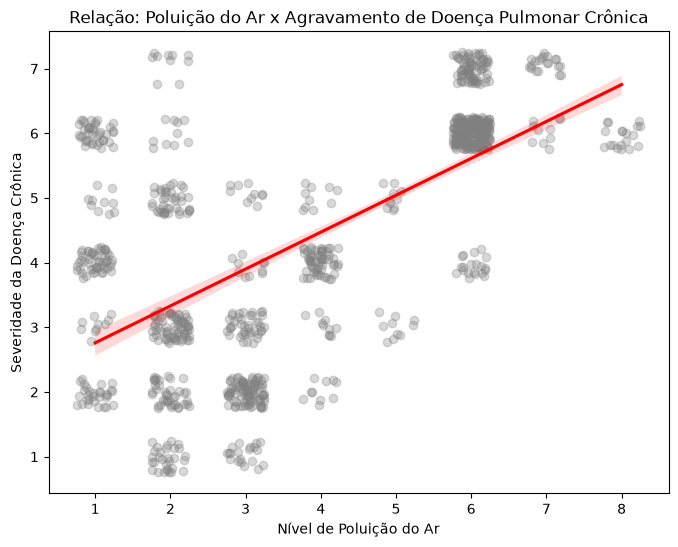

Como suposto anteriormente na ATA do dia 31 de maio, podemos concluir que a variável 
chronic Lung Disease é causada majoritariamente por Fumar e Poluição do Ar


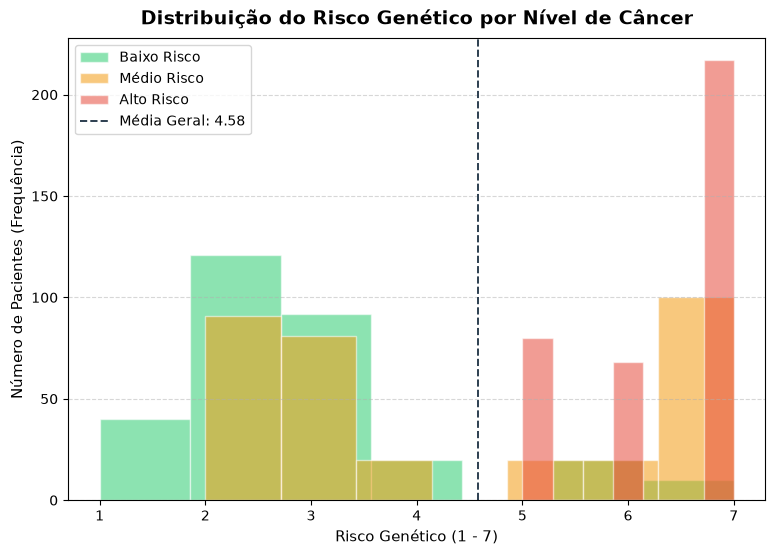

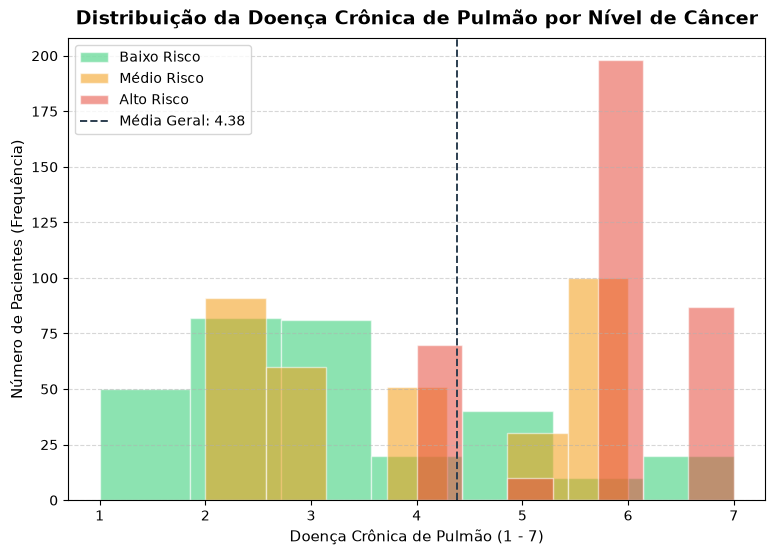

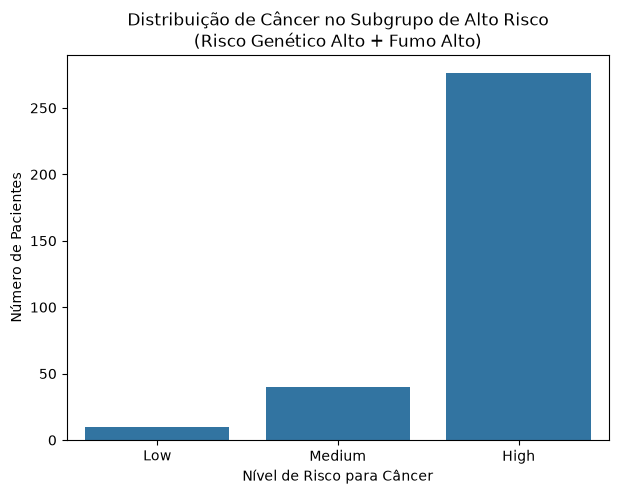

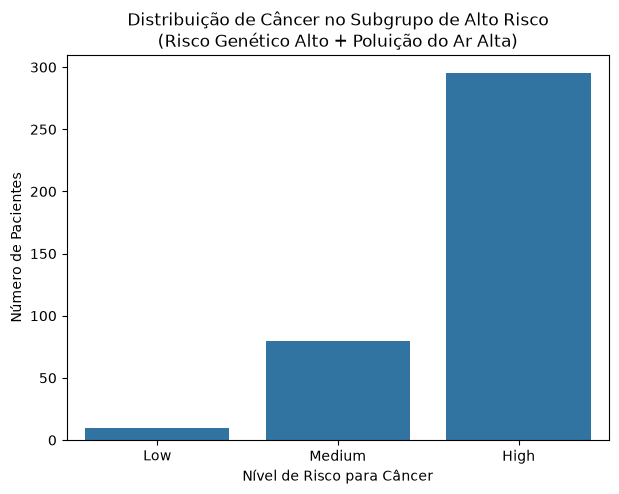

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_1 = pd.read_csv('Dataset(1).csv', index_col='index')
# Removendo os registros zerados no final do dataset
df_1 = df_1[df_1['Patient Id'] != '0']

# Transformando a variável alvo (Level) em numérica para a correlação funcionar
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df_1['Level'] = df_1['Level'].map(mapa)

# DEFININDO AS VARIÁVEIS DO CRUZAMENTO
G3 = ["Genetic Risk", "chronic Lung Disease"] 
# Cruzando o Grupo 3 com a variável Alvo (Level) e Demográficos (G5)
vars_all = G3 + ['Age', 'Gender', 'Level']

# CALCULANDO A MATRIZ DE CORRELAÇÃO
corr = df_1[vars_all].corr()

# PLOTAGEM DO GRÁFICO 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Correlação: Histórico Clínico (G3) × Demográficos e Risco (Level)',
             fontsize=14, fontweight='bold')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)

plt.show()

print("""
 ╔══════════════════════════════════════════════════════════════════╗
 ║  INSIGHTS — Correlação Histórico Clínico × Level × Demografia    ║
 ╠══════════════════════════════════════════════════════════════════╣
 ║  • O Risco Genético possui a maior correlação positiva com o     ║
 ║    Risco de Câncer. Isso indica um maior fator de risco, porém   ║
 ║    esperado. O mesmo ocorre, só que menos, com Doença Crônica.   ║
 ║  • Risco Genético e Doença Crônica possuem uma correlação muito  ║
 ║    alta entre si. Com isso, dá pra inferir que elas andam juntas ║
 ║    e dão informações redundantes ao modelo (multicolinearidade). ║
 ║    Pessoas com predisposição genética alta frequentemente        ║
 ║    desenvolvem doenças pulmonares crônicas.                      ║    
 ║  • Dataset indica pouca correlação com a idade e nenhuma com o   ║
 ║    gênero quanto ao Histórico Clínico e Risco de Câncer.         ║
 ╚══════════════════════════════════════════════════════════════════╝
""")

# Variável Mediadora (1 de 2)
#pouca_interferencia = df_1[(df_1['Air Pollution'] <= 5)]
plt.figure(figsize=(8, 6))
sns.regplot(x='Smoking', y='chronic Lung Disease', data=df_1,
            x_jitter=0.25, y_jitter=0.25, 
            scatter_kws={'alpha':0.3, 'color': 'gray'}, line_kws={'color':'red'})

plt.title("Relação: Fumo x Agravamento de Doença Pulmonar Crônica")
plt.xlabel("Nível de Tabagismo (Smoking)")
plt.ylabel("Severidade da Doença Crônica")
plt.show()
# Variável Mediadora (2 de 2)
#pouca_interferencia = df_1[(df_1['Smoking'] <= 5)]
plt.figure(figsize=(8, 6))
sns.regplot(x='Air Pollution', y='chronic Lung Disease', data=df_1,
            x_jitter=0.25, y_jitter=0.25, 
            scatter_kws={'alpha':0.3, 'color': 'gray'}, line_kws={'color':'red'})

plt.title("Relação: Poluição do Ar x Agravamento de Doença Pulmonar Crônica")
plt.xlabel("Nível de Poluição do Ar")
plt.ylabel("Severidade da Doença Crônica")
plt.show()
print("Como suposto anteriormente na ATA do dia 31 de maio, podemos concluir que a variável" \
" \nchronic Lung Disease é causada majoritariamente por Fumar e Poluição do Ar")


PALETTE_RISK = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
LABELS_RISK = {0: 'Baixo Risco', 1: 'Médio Risco', 2: 'Alto Risco'}

plt.figure(figsize=(9, 6))
for lv in [0, 1, 2]:
    subset = df_1[df_1['Level'] == lv]['Genetic Risk']
    plt.hist(subset, bins=7, alpha=0.55, color=PALETTE_RISK[lv], 
             label=LABELS_RISK[lv], edgecolor='white')
media1 = df_1['Genetic Risk'].mean()
plt.axvline(media1, color='#2c3e50', linestyle='--', linewidth=1.4,
            label=f'Média Geral: {media1:.2f}')
plt.title("Distribuição do Risco Genético por Nível de Câncer", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Risco Genético (1 - 7)", fontsize=11)
plt.ylabel("Número de Pacientes (Frequência)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(9, 6))
for lv in [0, 1, 2]:
    subset = df_1[df_1['Level'] == lv]['chronic Lung Disease']
    plt.hist(subset, bins=7, alpha=0.55, color=PALETTE_RISK[lv], 
             label=LABELS_RISK[lv], edgecolor='white')
media2 = df_1['chronic Lung Disease'].mean()
plt.axvline(media2, color='#2c3e50', linestyle='--', linewidth=1.4,
            label=f'Média Geral: {media2:.2f}')
plt.title("Distribuição da Doença Crônica de Pulmão por Nível de Câncer", fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Doença Crônica de Pulmão (1 - 7)", fontsize=11)
plt.ylabel("Número de Pacientes (Frequência)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Subgrupo de alto risco (1 de 2)
combo_fatal1 = df_1[(df_1['Genetic Risk'] >= 5) & (df_1['Smoking'] >= 5)]
plt.figure(figsize=(7, 5))
sns.countplot(x='Level', data=combo_fatal1, order=[0, 1, 2])
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.title("Distribuição de Câncer no Subgrupo de Alto Risco\n(Risco Genético Alto + Fumo Alto)")
plt.ylabel("Número de Pacientes")
plt.xlabel("Nível de Risco para Câncer")
plt.show()

# Subgrupo de alto risco (1 de 2)
combo_fatal2 = df_1[(df_1['Genetic Risk'] >= 5) & (df_1['Air Pollution'] >= 5)]
plt.figure(figsize=(7, 5))
sns.countplot(x='Level', data=combo_fatal2, order=[0, 1, 2])
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.title("Distribuição de Câncer no Subgrupo de Alto Risco\n(Risco Genético Alto + Poluição do Ar Alta)")
plt.ylabel("Número de Pacientes")
plt.xlabel("Nível de Risco para Câncer")
plt.show()

